In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [3]:
data = pd.read_csv('meal.csv', encoding='latin-1')

In [4]:
data

,Category,Trimester,Age,BMI_Category,Ethnicity,Dietary_Preference,Diabetes,High_BP,Anemia,Allergies
0,6,T1,18,Underweight,Sinhala,Any,No,No,No,NaN
1,4,T1,18,Underweight,Sinhala,Any,No,No,Yes,NaN
2,3,T1,19,Underweight,Sinhala,Any,No,Yes,No,NaN
3,1,T1,19,Underweight,Sinhala,Any,No,Yes,Yes,NaN
4,2,T1,19,Underweight,Sinhala,Any,Yes,No,No,NaN
...,...,...,...,...,...,...,...,...,...,...
6907,1,T3,36,Obese,Muslim,Vegetarian,No,Yes,Yes,Red meat
6908,2,T3,39,Obese,Muslim,Vegetarian,Yes,No,No,Red meat
6909,1,T3,40,Obese,Muslim,Vegetarian,Yes,No,Yes,Red meat
6910,1,T3,35,Obese,Muslim,Vegetarian,Yes,Yes,No,Red meat


<Axes: >

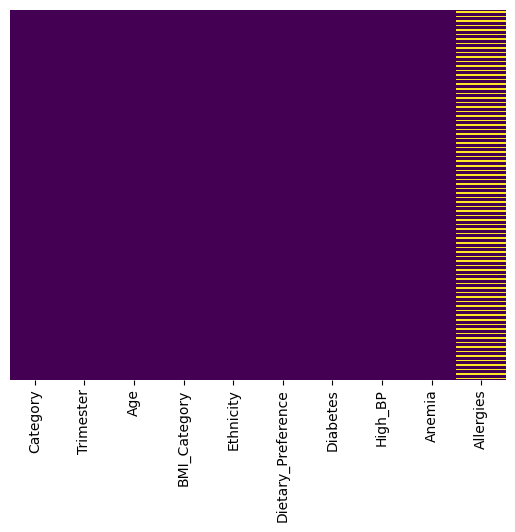

In [5]:
sns.heatmap(data.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [6]:
data.isnull().sum()

Category                 0
Trimester                0
Age                      0
BMI_Category             0
Ethnicity                0
Dietary_Preference       0
Diabetes                 0
High_BP                  0
Anemia                   0
Allergies             2304
dtype: int64

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6912 entries, 0 to 6911
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Category            6912 non-null   int64 
 1   Trimester           6912 non-null   object
 2   Age                 6912 non-null   int64 
 3   BMI_Category        6912 non-null   object
 4   Ethnicity           6912 non-null   object
 5   Dietary_Preference  6912 non-null   object
 6   Diabetes            6912 non-null   object
 7   High_BP             6912 non-null   object
 8   Anemia              6912 non-null   object
 9   Allergies           4608 non-null   object
dtypes: int64(2), object(8)
memory usage: 540.1+ KB


In [8]:
data

,Category,Trimester,Age,BMI_Category,Ethnicity,Dietary_Preference,Diabetes,High_BP,Anemia,Allergies
0,6,T1,18,Underweight,Sinhala,Any,No,No,No,NaN
1,4,T1,18,Underweight,Sinhala,Any,No,No,Yes,NaN
2,3,T1,19,Underweight,Sinhala,Any,No,Yes,No,NaN
3,1,T1,19,Underweight,Sinhala,Any,No,Yes,Yes,NaN
4,2,T1,19,Underweight,Sinhala,Any,Yes,No,No,NaN
...,...,...,...,...,...,...,...,...,...,...
6907,1,T3,36,Obese,Muslim,Vegetarian,No,Yes,Yes,Red meat
6908,2,T3,39,Obese,Muslim,Vegetarian,Yes,No,No,Red meat
6909,1,T3,40,Obese,Muslim,Vegetarian,Yes,No,Yes,Red meat
6910,1,T3,35,Obese,Muslim,Vegetarian,Yes,Yes,No,Red meat


In [9]:
data['BMI_Category'].value_counts()

BMI_Category
Underweight    1728
Normal         1728
Overweight     1728
Obese          1728
Name: count, dtype: int64

In [10]:
data['Trimester'].value_counts()

Trimester
T1    2304
T2    2304
T3    2304
Name: count, dtype: int64

In [11]:
data['Ethnicity'].value_counts()

Ethnicity
Sinhala    2304
Tamil      2304
Muslim     2304
Name: count, dtype: int64

In [12]:
data['Allergies'].value_counts()

Allergies
Shellfish    2304
Red meat     2304
Name: count, dtype: int64

In [13]:
data["Allergies"].fillna("No", inplace=True)

C:\Users\Kale\AppData\Local\Temp\ipykernel_16440\1902016438.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Allergies"].fillna("No", inplace=True)


In [14]:
data['Allergies'].value_counts()

Allergies
No           2304
Shellfish    2304
Red meat     2304
Name: count, dtype: int64

In [15]:
data

,Category,Trimester,Age,BMI_Category,Ethnicity,Dietary_Preference,Diabetes,High_BP,Anemia,Allergies
0,6,T1,18,Underweight,Sinhala,Any,No,No,No,No
1,4,T1,18,Underweight,Sinhala,Any,No,No,Yes,No
2,3,T1,19,Underweight,Sinhala,Any,No,Yes,No,No
3,1,T1,19,Underweight,Sinhala,Any,No,Yes,Yes,No
4,2,T1,19,Underweight,Sinhala,Any,Yes,No,No,No
...,...,...,...,...,...,...,...,...,...,...
6907,1,T3,36,Obese,Muslim,Vegetarian,No,Yes,Yes,Red meat
6908,2,T3,39,Obese,Muslim,Vegetarian,Yes,No,No,Red meat
6909,1,T3,40,Obese,Muslim,Vegetarian,Yes,No,Yes,Red meat
6910,1,T3,35,Obese,Muslim,Vegetarian,Yes,Yes,No,Red meat


In [16]:
label_encoders = {}
for col in ["BMI_Category", "Trimester", "Ethnicity", "Dietary_Preference","Diabetes","High_BP","Anemia", "Allergies"]:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le
    print(f"\n{col} mapping:")
    print(dict(zip(le.classes_, le.transform(le.classes_))))


BMI_Category mapping:
{'Normal': 0, 'Obese': 1, 'Overweight': 2, 'Underweight': 3}

Trimester mapping:
{'T1': 0, 'T2': 1, 'T3': 2}

Ethnicity mapping:
{'Muslim': 0, 'Sinhala': 1, 'Tamil': 2}

Dietary_Preference mapping:
{'Any': 0, 'Vegetarian': 1}

Diabetes mapping:
{'No': 0, 'Yes': 1}

High_BP mapping:
{'No': 0, 'Yes': 1}

Anemia mapping:
{'No': 0, 'Yes': 1}

Allergies mapping:
{'No': 0, 'Red meat': 1, 'Shellfish': 2}


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6912 entries, 0 to 6911
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Category            6912 non-null   int64
 1   Trimester           6912 non-null   int32
 2   Age                 6912 non-null   int64
 3   BMI_Category        6912 non-null   int32
 4   Ethnicity           6912 non-null   int32
 5   Dietary_Preference  6912 non-null   int32
 6   Diabetes            6912 non-null   int32
 7   High_BP             6912 non-null   int32
 8   Anemia              6912 non-null   int32
 9   Allergies           6912 non-null   int32
dtypes: int32(8), int64(2)
memory usage: 324.1 KB


In [18]:
data.describe()

,Category,Trimester,Age,BMI_Category,Ethnicity,Dietary_Preference,Diabetes,High_BP,Anemia,Allergies
count,6912.000000,6912.000000,6912.000000,6912.000000,6912.000000,6912.000000,6912.000000,6912.000000,6912.000000,6912.000000
mean,2.364583,1.000000,28.254485,1.500000,1.000000,0.500000,0.500000,0.500000,0.500000,1.000000
std,1.790069,0.816556,7.634591,1.118115,0.816556,0.500036,0.500036,0.500036,0.500036,0.816556
min,1.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,19.750000,0.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.500000,1.000000,29.500000,1.500000,1.000000,0.500000,0.500000,0.500000,0.500000,1.000000
75%,3.250000,2.000000,34.250000,2.250000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000
max,10.000000,2.000000,41.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000


In [19]:
data.isnull().sum()

Category              0
Trimester             0
Age                   0
BMI_Category          0
Ethnicity             0
Dietary_Preference    0
Diabetes              0
High_BP               0
Anemia                0
Allergies             0
dtype: int64

In [20]:
X = data[['Age','BMI_Category','Trimester','Ethnicity','Dietary_Preference','Diabetes','High_BP',"Anemia",'Allergies']]
y = data[['Category']]

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [22]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Category Accuracy:", accuracy_score(y_test, y_pred))

Category Accuracy: 1.0


In [23]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Category Accuracy (RF):", accuracy_score(y_test, rf.predict(X_test)))

c:\Users\Kale\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Category Accuracy (RF): 1.0


In [24]:
pickle.dump(model, open("m_model.dat", "wb"))

In [25]:
with open('m_model.dat' , 'rb') as f:
    m_model = pickle.load(f)

In [26]:
X_train

,Age,BMI_Category,Trimester,Ethnicity,Dietary_Preference,Diabetes,High_BP,Anemia,Allergies
2886,28,3,1,1,0,1,1,0,0
547,18,1,0,0,0,0,1,1,1
2959,24,3,1,2,1,1,1,1,0
2694,19,2,1,0,0,1,1,0,0
4953,19,2,2,2,0,0,0,1,2
...,...,...,...,...,...,...,...,...,...
3738,30,0,1,0,1,0,1,0,1
998,28,2,0,0,1,1,1,0,2
5376,20,0,2,2,0,0,0,0,0
4891,19,0,2,0,1,0,1,1,1


In [27]:
y_train

,Category
2886,1
547,1
2959,1
2694,1
4953,4
...,...
3738,3
998,1
5376,10
4891,1


In [28]:
m_model.predict([[30,2,1,1,1,1,0,1,0]])[0]

c:\Users\Kale\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1